# BreathAlert — Queimadas e Internações Respiratórias no Brasil (2016–2025)

**Global Solution 2026 · Ciência de Dados**

Este notebook investiga a relação entre os **focos de queimada** (INPE/BDQueimadas)
e as **internações respiratórias** do SUS (DATASUS/SIH, CID-10 Capítulo X), por
estado e mês, de 2016 a 2025, para fundamentar um sistema de alerta de risco
respiratório associado à fumaça das queimadas.

**Como executar:** o notebook lê três arquivos já consolidados —
`queimadas_consolidado.csv`, `datasus_consolidado.csv`, `populacao_consolidado.csv`
(e `queimadas_bioma_consolidado.csv`) — gerados pelo script
`gerar_dados_consolidados.py`. Assim ele roda de ponta a ponta sem depender das
pastas de dados brutos nem de acesso à internet.

## 1. Introdução ao problema

As queimadas liberam grande quantidade de material particulado na atmosfera,
associado na literatura médica ao agravamento de doenças respiratórias (asma,
bronquite, DPOC). Este projeto cruza duas bases públicas — focos de queimada
(INPE) e internações respiratórias (DATASUS) — para investigar, **com dados**,
se e como a intensidade das queimadas se relaciona com as internações ao longo
do território e do tempo, e o que isso implica para um sistema de alerta.

## 2. Objetivos

**Geral:** avaliar a associação entre focos de queimada e internações
respiratórias no Brasil (2016–2025).

**Específicos:** tratar e consolidar as bases por estado/mês; caracterizar os
padrões espaciais e sazonais; cruzar as bases e medir correlação no mesmo mês e
com defasagem; identificar onde a associação é mais forte; e testar formalmente
se meses de queimada intensa são seguidos por aumento de internações.

## 3. Importação das bibliotecas e configuração

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Estatística
from scipy import stats

# Padronização visual de todos os gráficos do notebook
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)   # tamanho padrão
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

### Tabela de referência dos estados (fonte única de verdade)

Em vez de manter vários dicionários redundantes, definimos **uma** tabela com os
27 estados e derivamos dela todos os mapas (código→sigla, nome→sigla,
sigla→região etc.). Para corrigir qualquer coisa, basta editar a tabela `UFS`.

In [2]:
import unicodedata

# (código IBGE, sigla, nome, região)
UFS = [
    ("11","RO","Rondônia","Norte"),        ("12","AC","Acre","Norte"),
    ("13","AM","Amazonas","Norte"),        ("14","RR","Roraima","Norte"),
    ("15","PA","Pará","Norte"),            ("16","AP","Amapá","Norte"),
    ("17","TO","Tocantins","Norte"),       ("21","MA","Maranhão","Nordeste"),
    ("22","PI","Piauí","Nordeste"),        ("23","CE","Ceará","Nordeste"),
    ("24","RN","Rio Grande do Norte","Nordeste"), ("25","PB","Paraíba","Nordeste"),
    ("26","PE","Pernambuco","Nordeste"),   ("27","AL","Alagoas","Nordeste"),
    ("28","SE","Sergipe","Nordeste"),      ("29","BA","Bahia","Nordeste"),
    ("31","MG","Minas Gerais","Sudeste"),  ("32","ES","Espírito Santo","Sudeste"),
    ("33","RJ","Rio de Janeiro","Sudeste"),("35","SP","São Paulo","Sudeste"),
    ("41","PR","Paraná","Sul"),            ("42","SC","Santa Catarina","Sul"),
    ("43","RS","Rio Grande do Sul","Sul"), ("50","MS","Mato Grosso do Sul","Centro-Oeste"),
    ("51","MT","Mato Grosso","Centro-Oeste"),("52","GO","Goiás","Centro-Oeste"),
    ("53","DF","Distrito Federal","Centro-Oeste"),
]

def _sem_acento(txt):
    # 'SÃO PAULO' -> 'sao paulo' (minúsculo, sem acento)
    txt = str(txt).strip().lower()
    return "".join(c for c in unicodedata.normalize("NFKD", txt)
                   if not unicodedata.combining(c))

# mapas derivados automaticamente
mapa_uf         = {cod: sig for cod, sig, nome, reg in UFS}
nome_para_sigla = {_sem_acento(nome): sig for cod, sig, nome, reg in UFS}
sigla_para_nome = {sig: nome for cod, sig, nome, reg in UFS}
regiao_sigla    = {sig: reg for cod, sig, nome, reg in UFS}   # sigla  -> região
regiao_map      = {nome.upper(): reg for cod, sig, nome, reg in UFS}  # NOME -> região
siglas          = set(mapa_uf.values())

nome_mes = {1:"Jan",2:"Fev",3:"Mar",4:"Abr",5:"Mai",6:"Jun",
            7:"Jul",8:"Ago",9:"Set",10:"Out",11:"Nov",12:"Dez"}

def estado_para_sigla(valor):
    # Aceita sigla ('SP') OU nome completo ('SÃO PAULO') -> sigla
    v = str(valor).strip()
    if v.upper() in siglas:
        return v.upper()
    return nome_para_sigla.get(_sem_acento(v))

## 4. Carregamento dos dados consolidados

Lemos os arquivos já tratados. Cada um está no nível **Estado / Ano / Mês**:
- `queimadas_consolidado.csv` — focos e variáveis ambientais (INPE)
- `datasus_consolidado.csv` — internações respiratórias (SUS)
- `populacao_consolidado.csv` — população estimada por UF/ano (IBGE)
- `queimadas_bioma_consolidado.csv` — focos agregados por bioma

In [3]:
df_queimadas = pd.read_csv("dados/queimadas_consolidado.csv")
df_sus       = pd.read_csv("dados/datasus_consolidado.csv")
df_pop       = pd.read_csv("dados/populacao_consolidado.csv")
df_biomas    = pd.read_csv("dados/queimadas_bioma_consolidado.csv")

print("Queimadas:", df_queimadas.shape, "| colunas:", df_queimadas.columns.tolist())
print("SUS      :", df_sus.shape, "| colunas:", df_sus.columns.tolist())
print("População:", df_pop.shape)
print("Biomas   :", df_biomas.shape)
df_queimadas.head()

Queimadas: (3240, 7) | colunas: ['Estado', 'Ano', 'Mes', 'Qtd_Focos', 'Media_Risco', 'Media_DiasSemChuva', 'Media_FRP']
SUS      : (3240, 4) | colunas: ['Estado', 'Ano', 'Mes', 'Internacoes']
População: (270, 3)
Biomas   : (6, 5)


,Estado,Ano,Mes,Qtd_Focos,Media_Risco,Media_DiasSemChuva,Media_FRP
0,ACRE,2016,1,97,0.400000,1.546392,15.576923
1,ACRE,2016,2,18,0.247059,1.000000,12.500000
2,ACRE,2016,3,16,0.256250,1.312500,NaN
3,ACRE,2016,4,57,0.567857,1.508772,8.500000
4,ACRE,2016,5,200,0.675500,6.725000,19.570000


## 5. Análise exploratória — Queimadas

Antes de cruzar, é preciso entender cada base. Começamos pelas queimadas:
distribuição, estados que mais queimam, relação com variáveis ambientais,
biomas e sazonalidade.

### 5.1 Estatística descritiva dos focos por estado/mês

In [4]:
desc = df_queimadas["Qtd_Focos"].agg(["mean", "median", "std", "min", "max"])
print("Focos de queimada por estado/mês (2016-2025):")
print(f"  Média         : {desc['mean']:>12,.1f}")
print(f"  Mediana       : {desc['median']:>12,.1f}")
print(f"  Desvio padrão : {desc['std']:>12,.1f}")
print(f"  Mínimo        : {desc['min']:>12,.0f}")
print(f"  Máximo        : {desc['max']:>12,.0f}")

Focos de queimada por estado/mês (2016-2025):
  Média         :     12,695.7
  Mediana       :      1,408.0
  Desvio padrão :     39,594.3
  Mínimo        :            1
  Máximo        :      726,002


> **Leitura:** a mediana (~1.400) é muito menor que a média (~12.700). Isso
> indica uma distribuição **fortemente assimétrica** — poucos estados/meses
> concentram a maior parte dos focos, enquanto a maioria tem valores baixos.

### 5.2 Distribuição e outliers

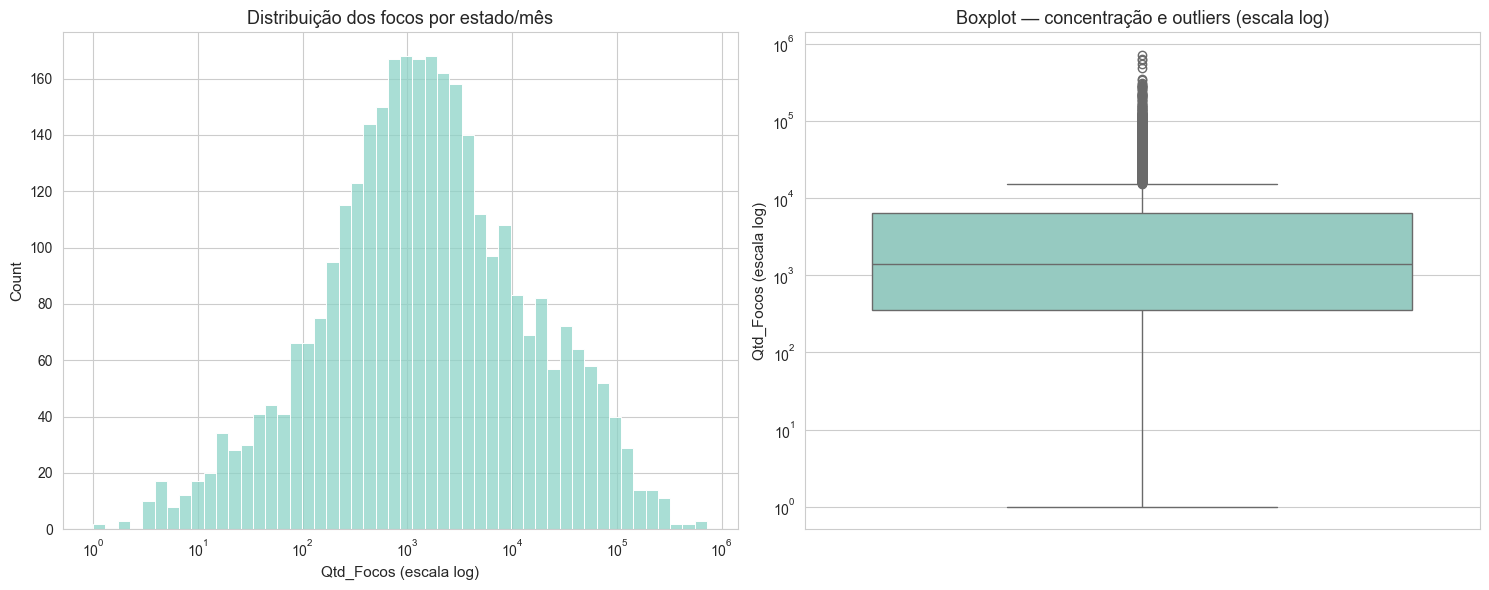

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df_queimadas["Qtd_Focos"], bins=50, log_scale=True, ax=axes[0])
axes[0].set_title("Distribuição dos focos por estado/mês")
axes[0].set_xlabel("Qtd_Focos (escala log)")

sns.boxplot(y=df_queimadas["Qtd_Focos"], ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Boxplot — concentração e outliers (escala log)")
axes[1].set_ylabel("Qtd_Focos (escala log)")

plt.tight_layout()
plt.show()

### 5.3 Ranking de estados — quem mais queima

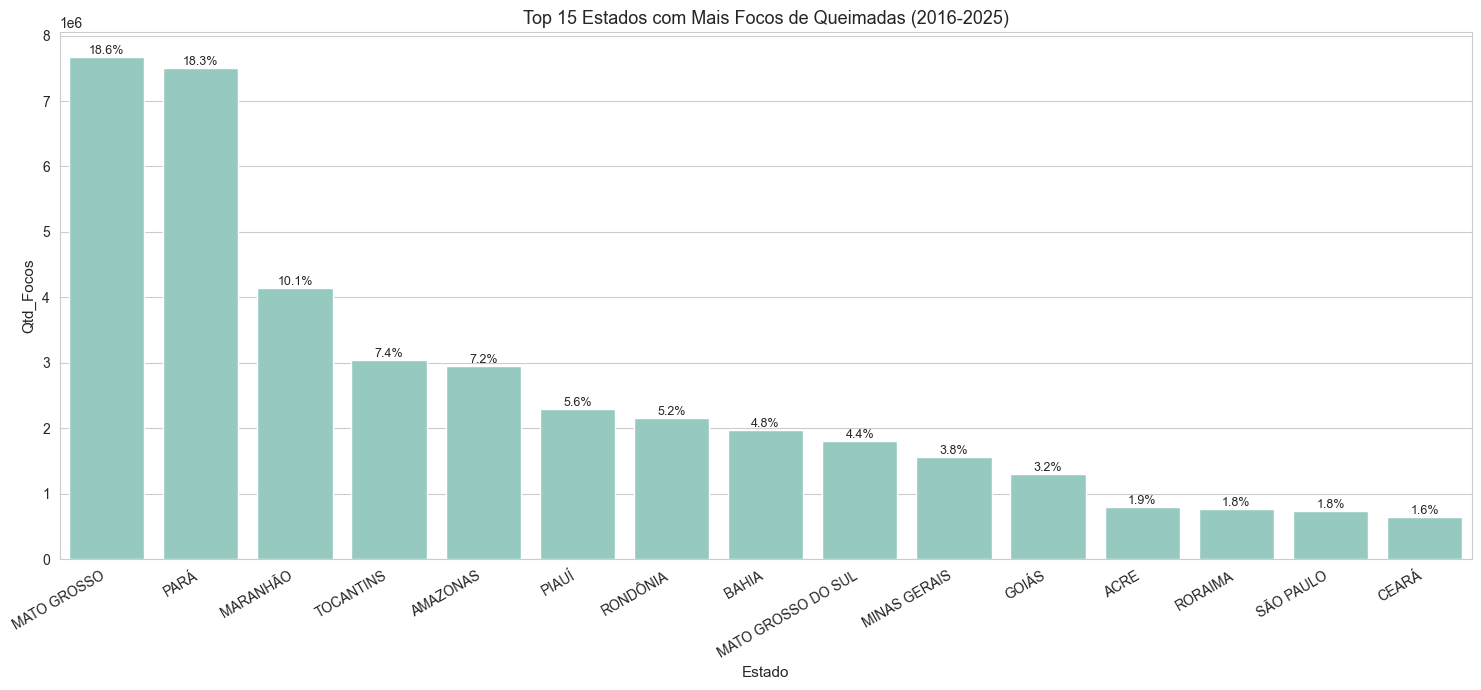

In [6]:
ranking_estados = (df_queimadas.groupby("Estado")["Qtd_Focos"].sum()
                   .reset_index().sort_values("Qtd_Focos", ascending=False))
ranking_estados["Perc_Total"] = (ranking_estados["Qtd_Focos"]
                                 / ranking_estados["Qtd_Focos"].sum() * 100)
top15 = ranking_estados.head(15)

plt.figure(figsize=(15, 7))
ax = sns.barplot(data=top15, x="Estado", y="Qtd_Focos")
for i, row in enumerate(top15.itertuples()):
    ax.text(i, row.Qtd_Focos, f"{row.Perc_Total:.1f}%", ha="center", va="bottom", fontsize=9)
plt.title("Top 15 Estados com Mais Focos de Queimadas (2016-2025)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

> **Leitura:** Mato Grosso e Pará concentram sozinhos quase **40%** de todos os
> focos da série — confirmando a concentração geográfica na fronteira agrícola
> (Amazônia/Cerrado).

### 5.4 Correlação entre focos e variáveis ambientais

In [7]:
base_mensal = df_queimadas.groupby(["Ano", "Mes"]).agg(
    Qtd_Focos          = ("Qtd_Focos", "sum"),
    Media_Risco        = ("Media_Risco", "mean"),
    Media_DiasSemChuva = ("Media_DiasSemChuva", "mean"),
    Media_FRP          = ("Media_FRP", "mean"),
).reset_index()

corr_ambiental = base_mensal[["Qtd_Focos", "Media_Risco",
                              "Media_DiasSemChuva", "Media_FRP"]].corr()
print("Correlação entre focos e variáveis de risco:")
print(corr_ambiental.round(3))

Correlação entre focos e variáveis de risco:
                    Qtd_Focos  Media_Risco  Media_DiasSemChuva  Media_FRP
Qtd_Focos               1.000        0.572               0.762      0.360
Media_Risco             0.572        1.000               0.700      0.392
Media_DiasSemChuva      0.762        0.700               1.000      0.145
Media_FRP               0.360        0.392               0.145      1.000


> **Leitura:** os **dias sem chuva** têm a correlação mais forte com a
> quantidade de focos (~0,76), mais até que o índice de risco oficial (~0,57).
> Ou seja, a seca acumulada é o melhor preditor ambiental de queimada na base.

### 5.5 Risco e seca por estado

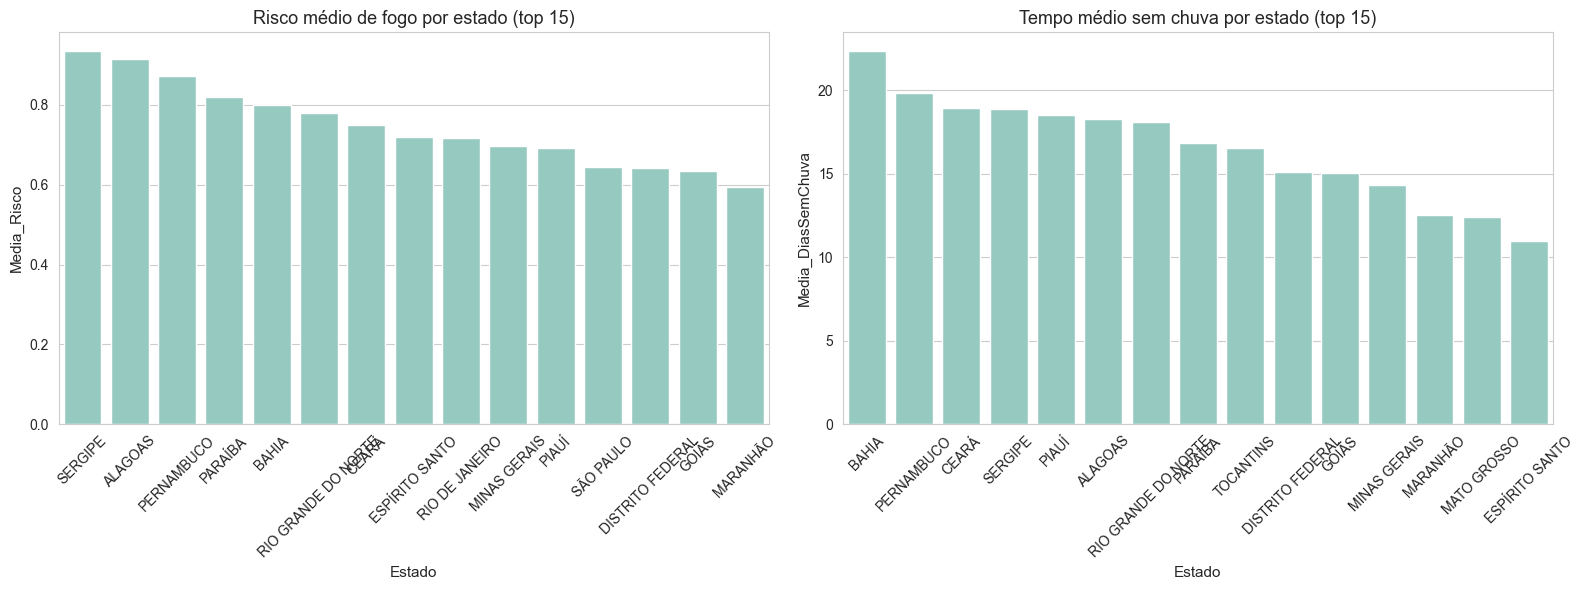

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

risco_estado = (df_queimadas.groupby("Estado")["Media_Risco"].mean()
                .sort_values(ascending=False).head(15).reset_index())
sns.barplot(data=risco_estado, x="Estado", y="Media_Risco", ax=axes[0])
axes[0].set_title("Risco médio de fogo por estado (top 15)")
axes[0].tick_params(axis="x", rotation=45)

seca_estado = (df_queimadas.groupby("Estado")["Media_DiasSemChuva"].mean()
               .sort_values(ascending=False).head(15).reset_index())
sns.barplot(data=seca_estado, x="Estado", y="Media_DiasSemChuva", ax=axes[1])
axes[1].set_title("Tempo médio sem chuva por estado (top 15)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 5.6 Biomas — volume e intensidade do fogo

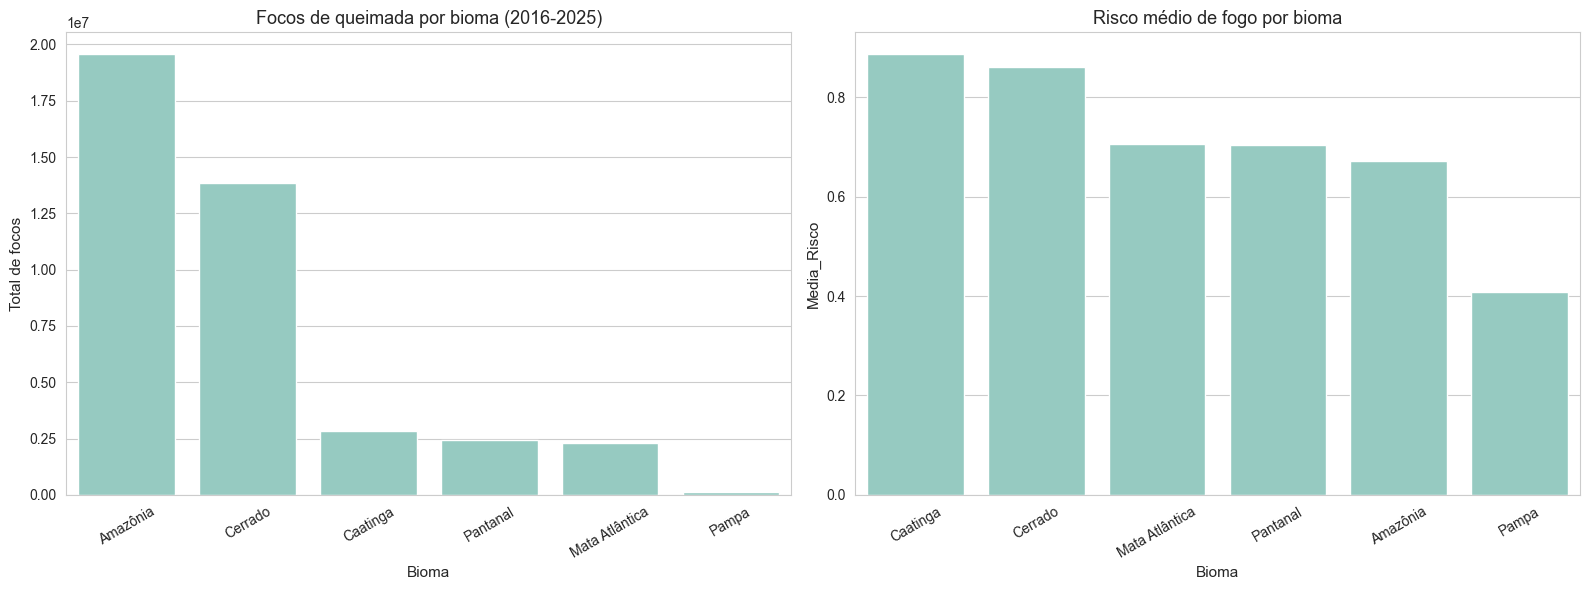

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df_biomas.sort_values("Qtd_Focos", ascending=False),
            x="Bioma", y="Qtd_Focos", ax=axes[0])
axes[0].set_title("Focos de queimada por bioma (2016-2025)")
axes[0].set_ylabel("Total de focos")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=df_biomas.sort_values("Media_Risco", ascending=False),
            x="Bioma", y="Media_Risco", ax=axes[1])
axes[1].set_title("Risco médio de fogo por bioma")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

> **Leitura:** a **Amazônia** lidera em volume de focos, mas com risco médio
> moderado (fogo ligado a desmatamento). **Cerrado** e **Caatinga** têm o maior
> risco e a maior seca — o Cerrado é o bioma mais crítico, combinando alto
> volume, alto risco e seca prolongada.

### 5.7 Sazonalidade dos focos

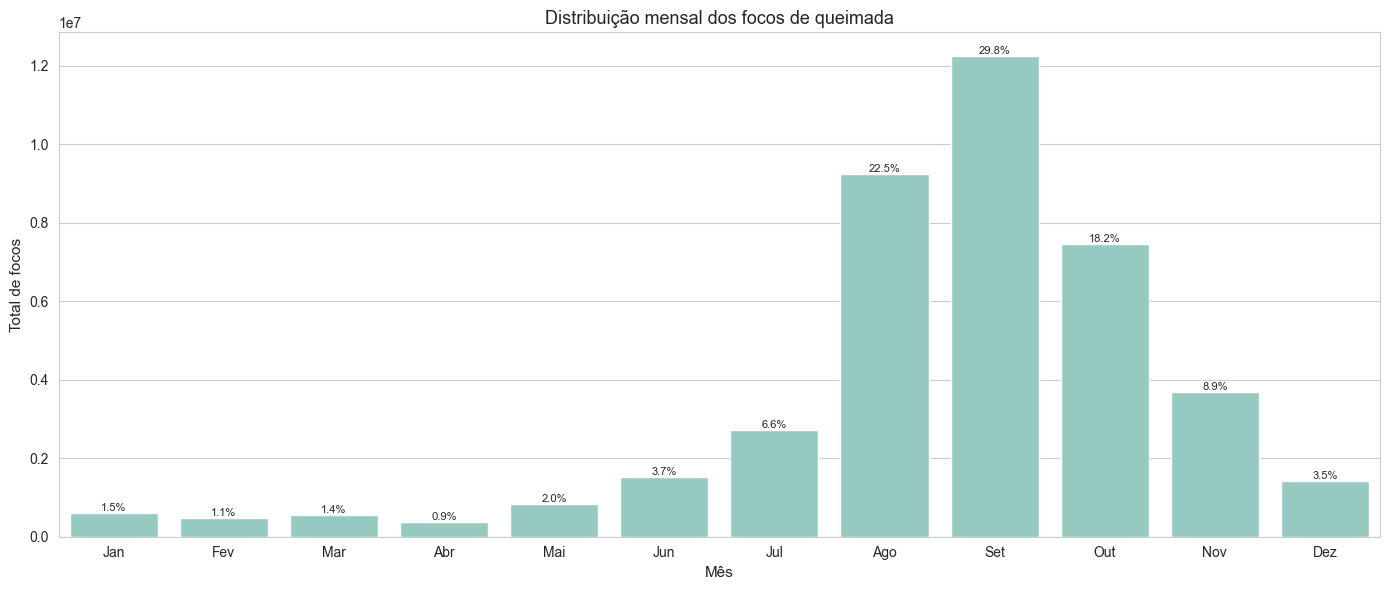

Ago+Set+Out concentram 70% dos focos do ano (pico da estação seca).


In [10]:
sazon = df_queimadas.groupby("Mes")["Qtd_Focos"].sum().reset_index()
sazon["Perc"] = sazon["Qtd_Focos"] / sazon["Qtd_Focos"].sum() * 100
sazon["Mes_Nome"] = sazon["Mes"].map(nome_mes)

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=sazon, x="Mes_Nome", y="Qtd_Focos")
for i, row in enumerate(sazon.itertuples()):
    ax.text(i, row.Qtd_Focos, f"{row.Perc:.1f}%", ha="center", va="bottom", fontsize=8)
plt.title("Distribuição mensal dos focos de queimada")
plt.xlabel("Mês"); plt.ylabel("Total de focos")
plt.tight_layout()
plt.show()

tri = sazon[sazon["Mes"].isin([8, 9, 10])]["Perc"].sum()
print(f"Ago+Set+Out concentram {tri:.0f}% dos focos do ano (pico da estação seca).")

> **Leitura:** as queimadas se concentram fortemente em **agosto–outubro**
> (~70% do ano), com pico em setembro. Esse é o calendário da estação seca.
> Guarde este resultado: ele será central no cruzamento, pois as **internações**
> têm um calendário diferente.

## 6. Análise exploratória — Internações respiratórias (SUS)

Mesma profundidade aplicada às internações: qualidade, distribuição, ranking,
evolução anual e sazonalidade. **Atenção:** aqui o Estado vem em **sigla** (SP),
diferente das queimadas (nome completo).

### 6.1 Raio-X de qualidade e estrutura

In [11]:
print("Estrutura:", df_sus.shape, "| colunas:", df_sus.columns.tolist())
print("\nQualidade:")
print(f"  Valores nulos: {df_sus.isna().sum().sum()}")
print(f"  Zeros em Internacoes: {(df_sus['Internacoes']==0).sum()}")
print(f"  Estados: {df_sus['Estado'].nunique()} (esperado 27)")
print(f"  Anos: {sorted(df_sus['Ano'].unique())}")
print(f"  Linhas: {len(df_sus)} (esperado 27 x 10 x 12 = 3240)")
print(f"  Duplicados (Estado/Ano/Mes): {df_sus.duplicated(['Estado','Ano','Mes']).sum()}")

desc = df_sus["Internacoes"].agg(["mean","median","std","min","max"])
print(f"\nInternações por estado/mês — média {desc['mean']:,.0f}, "
      f"mediana {desc['median']:,.0f}, máx {desc['max']:,.0f}")
print(f"Total no período: {df_sus['Internacoes'].sum():,}")

Estrutura: (3240, 4) | colunas: ['Estado', 'Ano', 'Mes', 'Internacoes']

Qualidade:
  Valores nulos: 0
  Zeros em Internacoes: 0
  Estados: 27 (esperado 27)
  Anos: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
  Linhas: 3240 (esperado 27 x 10 x 12 = 3240)
  Duplicados (Estado/Ano/Mes): 0

Internações por estado/mês — média 3,558, mediana 2,001, máx 31,141
Total no período: 11,528,960


> **Leitura:** base íntegra — sem nulos, sem zeros, 3.240 linhas (27×10×12),
> totalizando ~11,5 milhões de internações. Pronta para análise.

### 6.2 Distribuição das internações

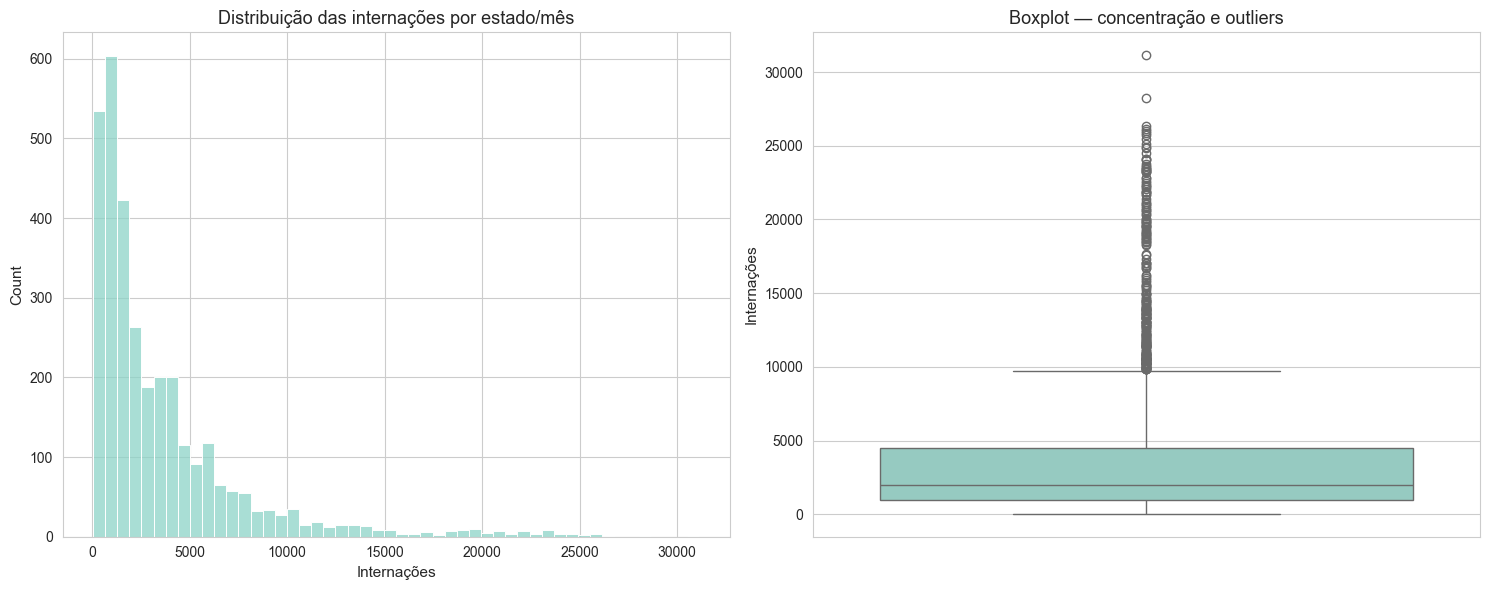

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(df_sus["Internacoes"], bins=50, ax=axes[0])
axes[0].set_title("Distribuição das internações por estado/mês")
axes[0].set_xlabel("Internações")
sns.boxplot(y=df_sus["Internacoes"], ax=axes[1])
axes[1].set_title("Boxplot — concentração e outliers")
axes[1].set_ylabel("Internações")
plt.tight_layout()
plt.show()

### 6.3 Ranking de estados — quem mais interna

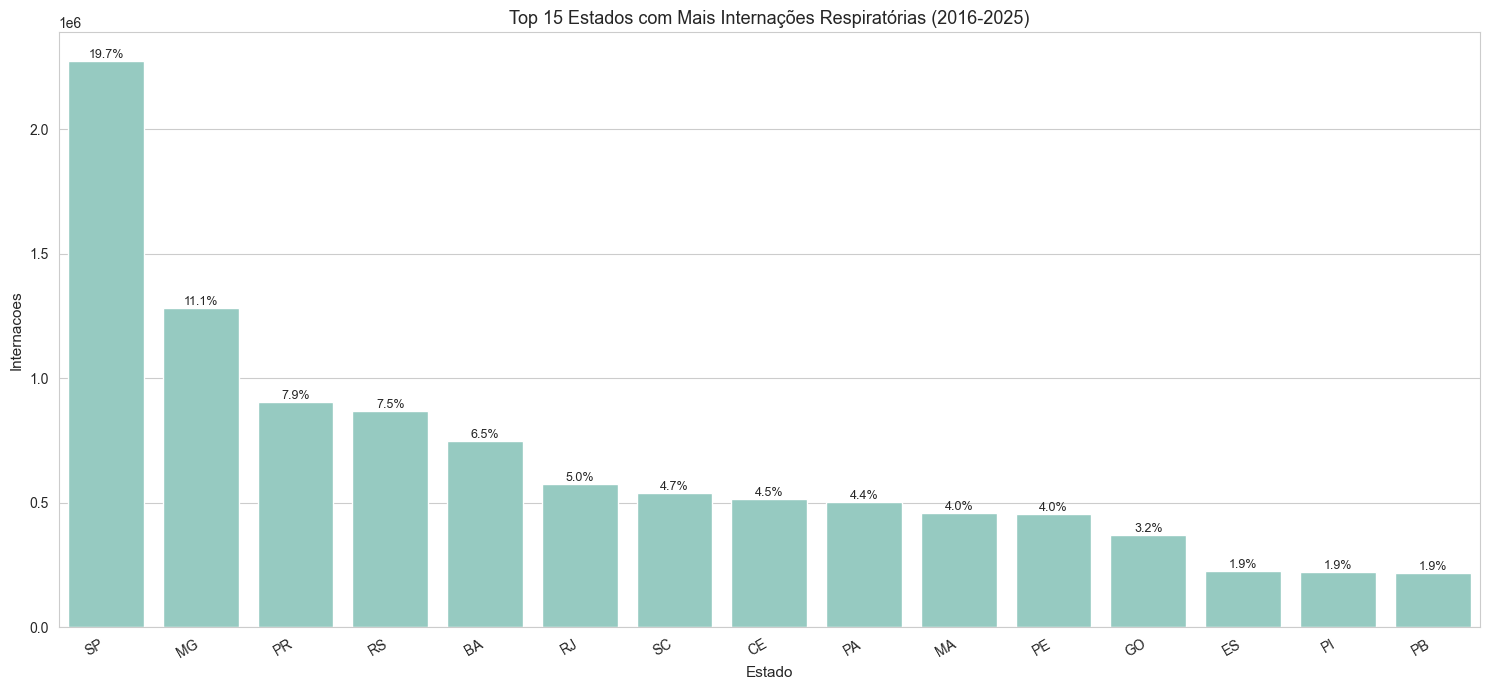

In [13]:
ranking_sus = (df_sus.groupby("Estado")["Internacoes"].sum()
               .reset_index().sort_values("Internacoes", ascending=False))
ranking_sus["Perc"] = ranking_sus["Internacoes"] / ranking_sus["Internacoes"].sum() * 100
top15s = ranking_sus.head(15)

plt.figure(figsize=(15, 7))
ax = sns.barplot(data=top15s, x="Estado", y="Internacoes")
for i, row in enumerate(top15s.itertuples()):
    ax.text(i, row.Internacoes, f"{row.Perc:.1f}%", ha="center", va="bottom", fontsize=9)
plt.title("Top 15 Estados com Mais Internações Respiratórias (2016-2025)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

> **Atenção metodológica:** este ranking é dominado por **população**, não por
> risco. SP lidera porque tem mais habitantes, não porque é mais perigoso. Isso
> difere das queimadas (onde o ranking refletia área queimada real). No
> cruzamento, consideraremos a **taxa por habitante** (seção 10).

### 6.4 Evolução anual — o vale da COVID

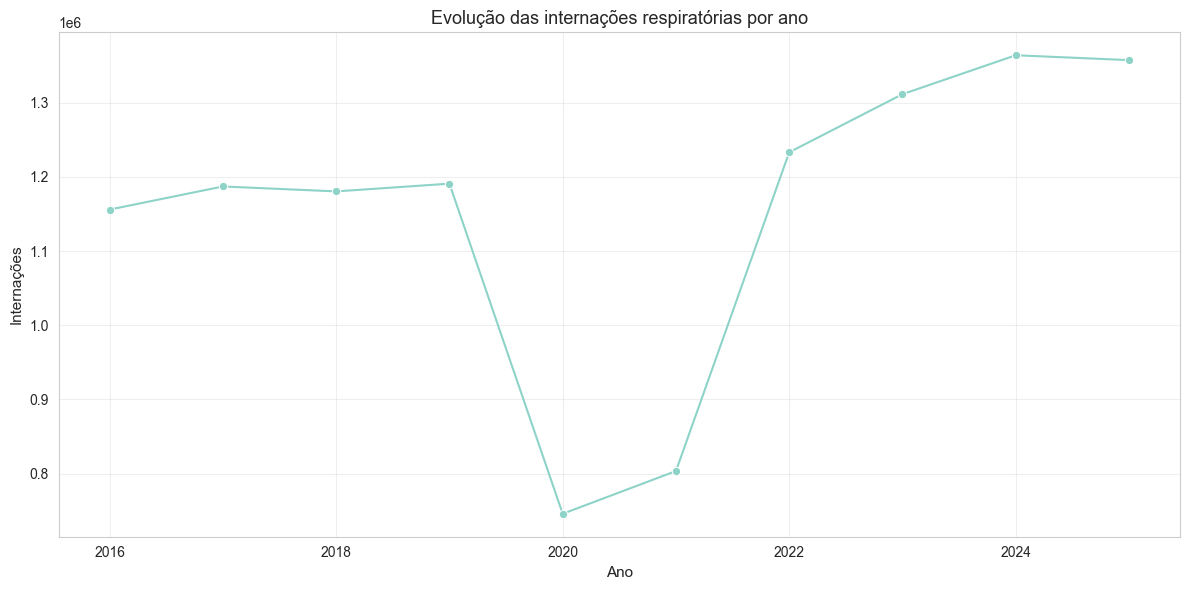

 Ano  Internacoes
2016      1155874
2017      1187002
2018      1180369
2019      1190791
2020       745729
2021       803361
2022      1233129
2023      1311452
2024      1363903
2025      1357350


In [14]:
evol = df_sus.groupby("Ano")["Internacoes"].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=evol, x="Ano", y="Internacoes", marker="o")
plt.title("Evolução das internações respiratórias por ano")
plt.ylabel("Internações"); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(evol.to_string(index=False))

> **Leitura:** queda acentuada em **2020–2021** (de ~1,1 mi para ~0,7 mi). É o
> efeito da pandemia: isolamento reduziu a circulação de vírus respiratórios e
> as idas ao hospital. A partir de 2022 há recuperação e tendência de alta.

### 6.5 Sazonalidade das internações

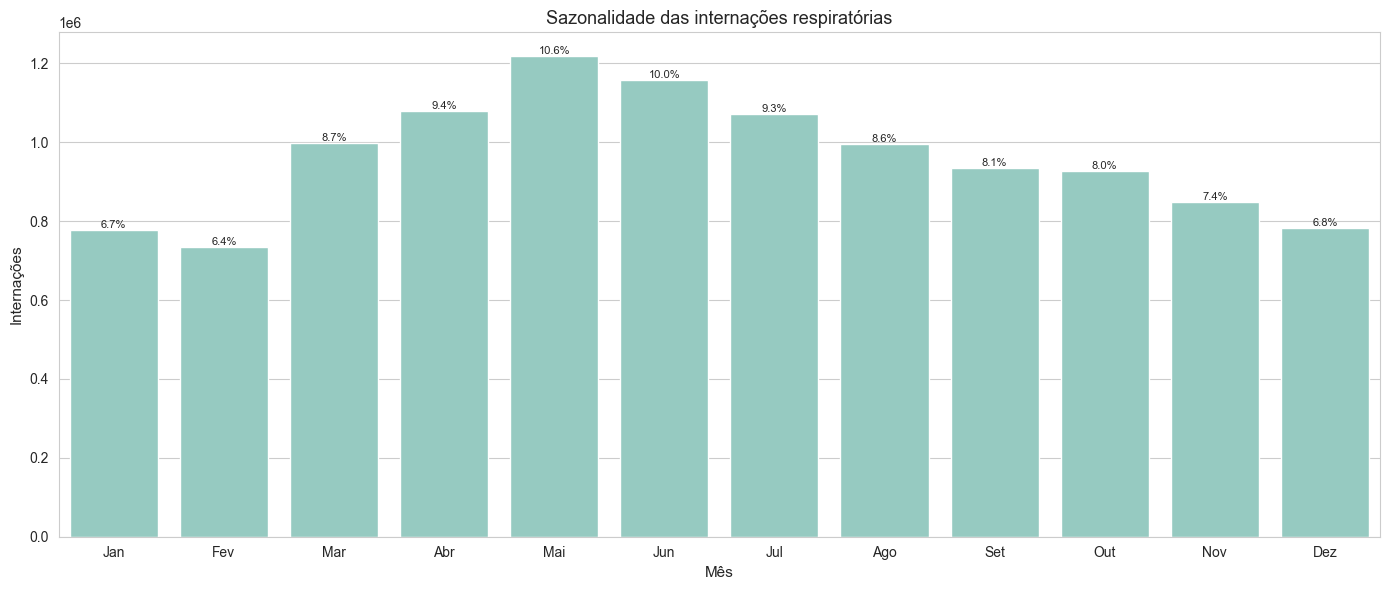

In [15]:
saz_sus = df_sus.groupby("Mes")["Internacoes"].sum().reset_index()
saz_sus["Perc"] = saz_sus["Internacoes"] / saz_sus["Internacoes"].sum() * 100
saz_sus["Mes_Nome"] = saz_sus["Mes"].map(nome_mes)

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=saz_sus, x="Mes_Nome", y="Internacoes")
for i, row in enumerate(saz_sus.itertuples()):
    ax.text(i, row.Internacoes, f"{row.Perc:.1f}%", ha="center", va="bottom", fontsize=8)
plt.title("Sazonalidade das internações respiratórias")
plt.xlabel("Mês"); plt.ylabel("Internações")
plt.tight_layout()
plt.show()

> **Leitura — INSIGHT CENTRAL DO PROJETO:** as internações sobem no
> **outono/inverno (abr–jun)**, por causa do frio e dos vírus respiratórios
> sazonais. Mas as **queimadas** sobem em **ago–out** (seção 5.7). Os dois picos
> **não coincidem** no calendário. Isso já antecipa que a relação queimada→
> internação não será "no mesmo mês" — terá de ser investigada com defasagem.

## 7. Cruzamento das bases

Para cruzar, as chaves precisam falar a mesma língua. O mês já é número nas duas;
falta converter o Estado das queimadas (nome completo) para **sigla**, como no SUS.

In [16]:
# converte o Estado das queimadas para sigla (em uma cópia, preservando o original)
df_queimadas_key = df_queimadas.copy()
df_queimadas_key["Estado"] = df_queimadas_key["Estado"].apply(estado_para_sigla)
print("Conversões que falharam (devem ser 0):", df_queimadas_key["Estado"].isna().sum())

# merge por Estado/Ano/Mes — outer + indicator para checar se algo fica órfão
base = pd.merge(df_queimadas_key, df_sus, on=["Estado","Ano","Mes"],
                how="outer", indicator=True)
print("\nResultado do cruzamento:")
print(base["_merge"].value_counts().to_string())

if (base["_merge"] != "both").sum() == 0:
    base = base.drop(columns=["_merge"])
    print("\n[OK] Cruzamento 1:1 perfeito — nenhuma linha órfã (3240 casadas).")
base.head()

Conversões que falharam (devem ser 0): 0

Resultado do cruzamento:
_merge
both          3240
left_only        0
right_only       0

[OK] Cruzamento 1:1 perfeito — nenhuma linha órfã (3240 casadas).


,Estado,Ano,Mes,Qtd_Focos,Media_Risco,Media_DiasSemChuva,Media_FRP,Internacoes
0,AC,2016,1,97,0.400000,1.546392,15.576923,273
1,AC,2016,2,18,0.247059,1.000000,12.500000,206
2,AC,2016,3,16,0.256250,1.312500,NaN,245
3,AC,2016,4,57,0.567857,1.508772,8.500000,348
4,AC,2016,5,200,0.675500,6.725000,19.570000,349


## 8. Correlação entre queimadas e internações

Investigamos em três níveis, do ingênuo ao correto — porque o jeito ingênuo
**engana**, e entender o porquê é metade da análise.

### 8.1 Nível 1 — correlação global (mesmo mês)

In [17]:
r, p   = stats.pearsonr(base["Qtd_Focos"], base["Internacoes"])
rs, ps = stats.spearmanr(base["Qtd_Focos"], base["Internacoes"])
print(f"Pearson : r = {r:+.3f} (p={p:.1e})")
print(f"Spearman: r = {rs:+.3f} (p={ps:.1e})")

Pearson : r = -0.039 (p=2.8e-02)
Spearman: r = +0.217 (p=9.5e-36)


> **Leitura:** Pearson dá ~0 (até levemente negativo). Mas esse número é
> **enganoso** — está contaminado por um fator de confusão: a população.

### 8.2 Por que engana — o confundidor populacional

In [18]:
ag = base.groupby("Estado").agg(Focos=("Qtd_Focos","sum"),
                                Internacoes=("Internacoes","sum"))
print("Estados que MAIS QUEIMAM:")
print(ag.sort_values("Focos", ascending=False).head(3).to_string())
print("\nEstados que MAIS INTERNAM:")
print(ag.sort_values("Internacoes", ascending=False).head(3).to_string())

Estados que MAIS QUEIMAM:
          Focos  Internacoes
Estado                      
MT      7666968       192730
PA      7507875       505695
MA      4138790       458061

Estados que MAIS INTERNAM:
          Focos  Internacoes
Estado                      
SP       729835      2275710
MG      1553279      1283405
PR       337830       906036


> **Leitura:** os estados que mais queimam (MT, PA) **não** são os que mais
> internam (SP, MG). A internação é movida por população. Misturar todos os
> estados num único cálculo mede a diferença entre estados, não a relação
> temporal que nos interessa.

### 8.3 Visualizando o confundidor

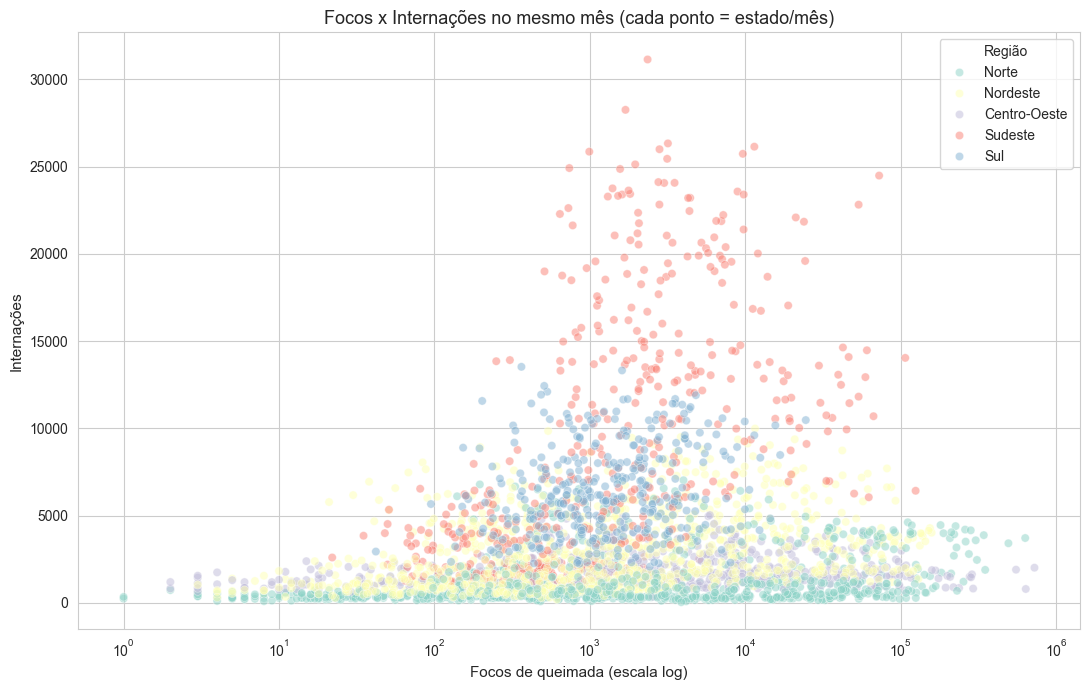

In [19]:
base["Regiao"] = base["Estado"].map(regiao_sigla)
plt.figure(figsize=(11, 7))
sns.scatterplot(data=base, x="Qtd_Focos", y="Internacoes", hue="Regiao", alpha=0.5)
plt.xscale("log")
plt.xlabel("Focos de queimada (escala log)"); plt.ylabel("Internações")
plt.title("Focos x Internações no mesmo mês (cada ponto = estado/mês)")
plt.legend(title="Região")
plt.tight_layout()
plt.show()

### 8.4 Nível 2 — correlação DENTRO de cada estado (controla população)

Média das correlações por estado: -0.098
Estados com r > 0: 7 de 27


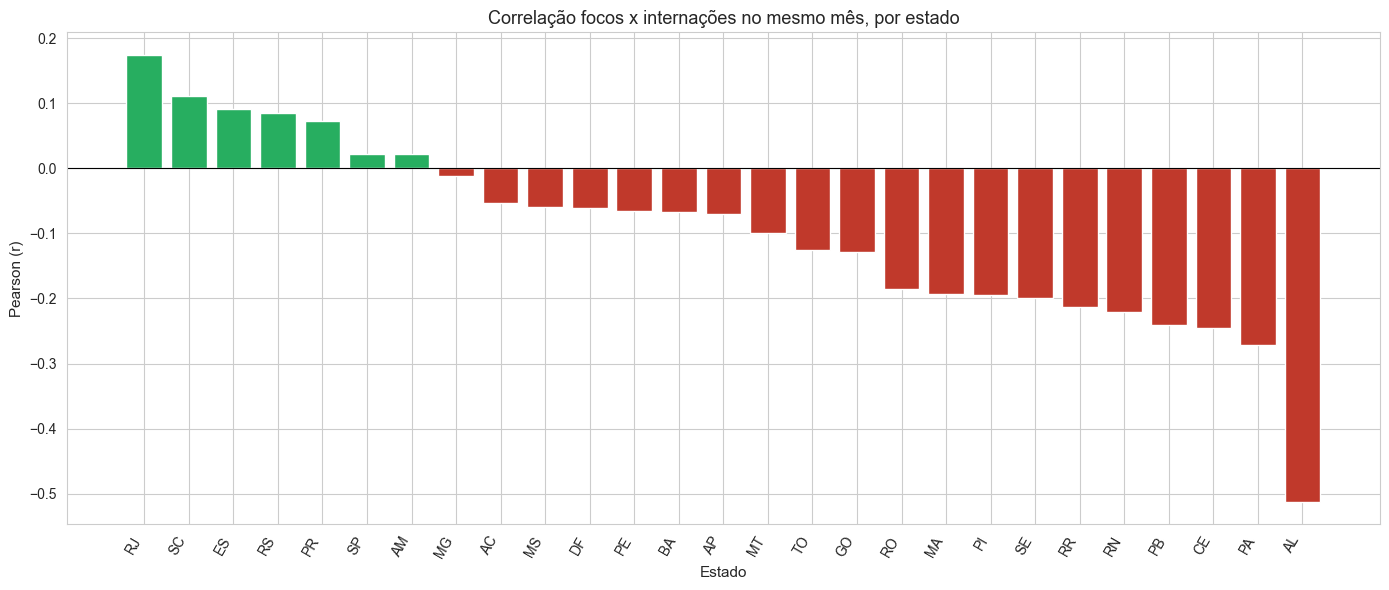

In [20]:
correlacoes = []
for uf, g in base.groupby("Estado"):
    if g["Qtd_Focos"].std() > 0 and g["Internacoes"].std() > 0:
        rr, pp = stats.pearsonr(g["Qtd_Focos"], g["Internacoes"])
        correlacoes.append({"Estado": uf, "r": rr, "p_valor": pp})
corr_estados = pd.DataFrame(correlacoes).sort_values("r", ascending=False)
print(f"Média das correlações por estado: {corr_estados['r'].mean():+.3f}")
print(f"Estados com r > 0: {(corr_estados['r']>0).sum()} de {len(corr_estados)}")

plt.figure(figsize=(14, 6))
cores = ["#c0392b" if v < 0 else "#27ae60" for v in corr_estados["r"]]
plt.bar(corr_estados["Estado"], corr_estados["r"], color=cores)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Correlação focos x internações no mesmo mês, por estado")
plt.ylabel("Pearson (r)"); plt.xlabel("Estado")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

> **Leitura:** mesmo controlando população, no mesmo mês a relação é fraca e
> frequentemente **negativa**. Faz sentido: quando a queimada está no auge
> (set), a internação já caiu da temporada de inverno. Os estados positivos são
> majoritariamente do **Sul/Sudeste**; os negativos, do **Norte/Nordeste**.
> Isso aponta para a necessidade de testar **defasagem**.

### 8.5 Nível 3 — defasagem temporal (lag)

In [21]:
base = base.sort_values(["Estado","Ano","Mes"]).reset_index(drop=True)

def corr_lag(df, col_focos, col_inter, lag):
    # Correlação média (dentro de cada estado) entre focos de (t-lag) e
    # internações de t. Calcular por estado controla a população.
    rs = []
    for uf, g in df.groupby("Estado"):
        g = g.sort_values(["Ano","Mes"])
        fdef = g[col_focos].shift(lag); inter = g[col_inter]
        m = fdef.notna() & inter.notna()
        if m.sum() > 10 and fdef[m].std() > 0:
            rs.append(stats.pearsonr(fdef[m], inter[m])[0])
    return np.mean(rs)

print("ABORDAGEM 1 — defasagem nos valores brutos:")
for lag in range(5):
    print(f"  lag {lag}: r = {corr_lag(base,'Qtd_Focos','Internacoes',lag):+.3f}")

ABORDAGEM 1 — defasagem nos valores brutos:
  lag 0: r = -0.098
  lag 1: r = -0.165
  lag 2: r = -0.192
  lag 3: r = -0.165
  lag 4: r = -0.105


> **Leitura:** a defasagem crua dá **negativo** e mais forte com o lag. Isso
> ainda não é o efeito da fumaça — é o reflexo dos dois ciclos sazonais estarem
> fora de fase. Precisamos remover a sazonalidade.

### 8.6 Removendo a sazonalidade — anomalias

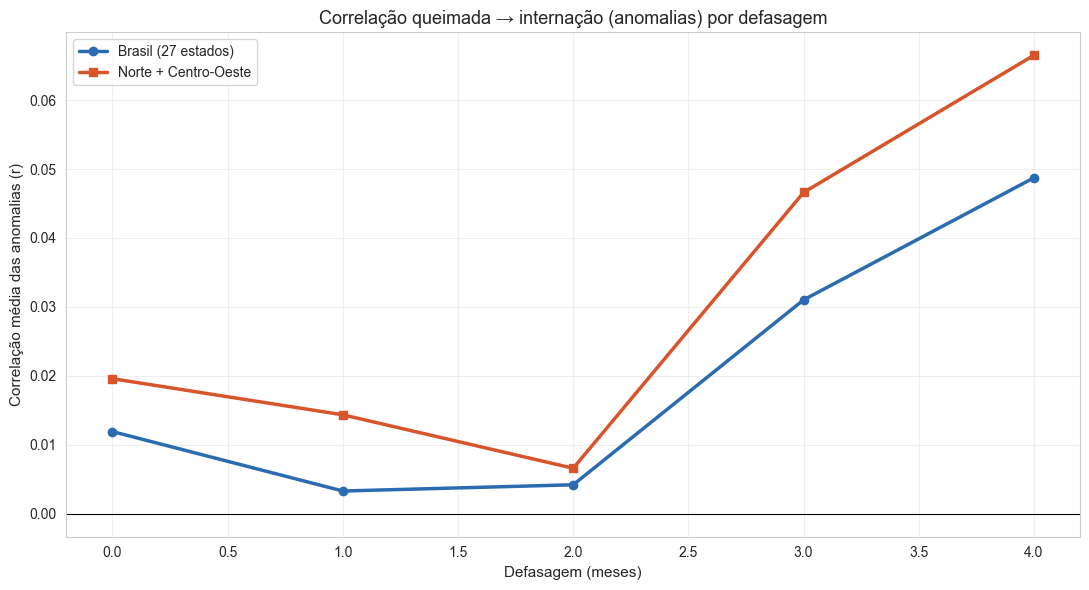

 lag  Brasil  Norte+CO
   0   0.012     0.020
   1   0.003     0.014
   2   0.004     0.007
   3   0.031     0.047
   4   0.049     0.067


In [22]:
# anomalia = valor - média daquele (estado, mês) ao longo dos anos
# responde: o mês ficou ACIMA ou ABAIXO do seu normal?
base["Focos_anom"] = base["Qtd_Focos"]   - base.groupby(["Estado","Mes"])["Qtd_Focos"].transform("mean")
base["Inter_anom"] = base["Internacoes"] - base.groupby(["Estado","Mes"])["Internacoes"].transform("mean")

fogo = base[base["Regiao"].isin(["Norte","Centro-Oeste"])]
comp = []
for lag in range(5):
    comp.append({"lag": lag,
                 "Brasil":   corr_lag(base, "Focos_anom", "Inter_anom", lag),
                 "Norte+CO": corr_lag(fogo, "Focos_anom", "Inter_anom", lag)})
comp = pd.DataFrame(comp)

plt.figure(figsize=(11, 6))
plt.plot(comp["lag"], comp["Brasil"], marker="o", color="#2b6cb0", linewidth=2.5,
         label="Brasil (27 estados)")
plt.plot(comp["lag"], comp["Norte+CO"], marker="s", color="#d8542b", linewidth=2.5,
         label="Norte + Centro-Oeste")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Correlação queimada → internação (anomalias) por defasagem")
plt.xlabel("Defasagem (meses)"); plt.ylabel("Correlação média das anomalias (r)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(comp.round(3).to_string(index=False))

> **Leitura — a virada:** removida a sazonalidade, a correlação deixa de ser
> negativa e fica **positiva, crescendo com a defasagem** (e mais forte nos
> estados de queimada intensa). É **coerente com a hipótese**: a fumaça agrava
> quadros nos meses seguintes. O sinal é **fraco** (r ~ +0,05 a +0,07): não
> prova causalidade, mas a direção e o padrão são consistentes.

## 9. Recortes regionais — onde o sinal aparece

A média do Brasil dilui o efeito. Aqui procuramos onde ele se mostra mais forte.

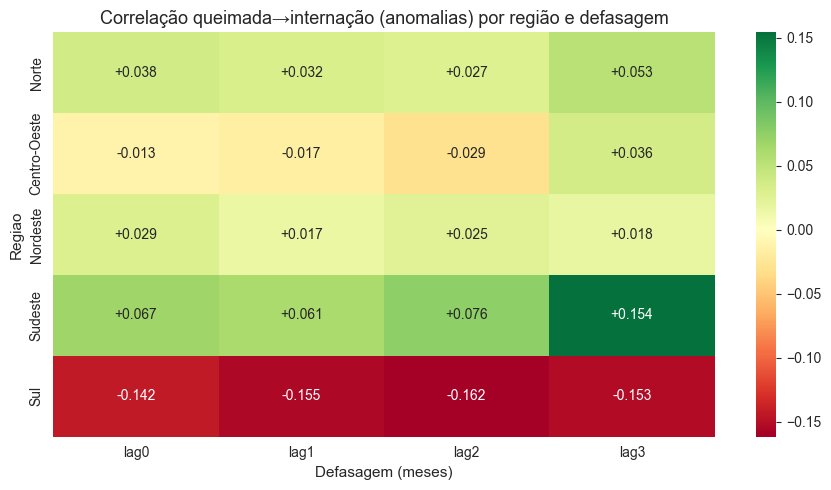

      Regiao   lag0   lag1   lag2   lag3
       Norte  0.038  0.032  0.027  0.053
Centro-Oeste -0.013 -0.017 -0.029  0.036
    Nordeste  0.029  0.017  0.025  0.018
     Sudeste  0.067  0.061  0.076  0.154
         Sul -0.142 -0.155 -0.162 -0.153


In [23]:
def corr_lag_anom(df, lag):
    rs = []
    for uf, g in df.groupby("Estado"):
        g = g.sort_values(["Ano","Mes"])
        fa = g["Focos_anom"].shift(lag); ia = g["Inter_anom"]
        m = fa.notna() & ia.notna()
        if m.sum() > 10 and fa[m].std() > 0:
            rs.append(stats.pearsonr(fa[m], ia[m])[0])
    return np.mean(rs) if rs else np.nan

tab = []
for reg in ["Norte","Centro-Oeste","Nordeste","Sudeste","Sul"]:
    sub = base[base["Regiao"] == reg]
    tab.append({"Regiao": reg, **{f"lag{l}": corr_lag_anom(sub, l) for l in range(4)}})
tab = pd.DataFrame(tab)

plt.figure(figsize=(9, 5))
sns.heatmap(tab.set_index("Regiao"), annot=True, fmt="+.3f", cmap="RdYlGn", center=0)
plt.title("Correlação queimada→internação (anomalias) por região e defasagem")
plt.xlabel("Defasagem (meses)")
plt.tight_layout()
plt.show()
print(tab.round(3).to_string(index=False))

> **Leitura:** o sinal mais forte está no **Sudeste**, crescendo até lag 3
> (+0,15). O **Sul** é negativo. A explicação provável: o Sudeste tem população
> grande, então a anomalia de internação é medida com pouco ruído — onde dá
> para **medir bem**, o efeito aparece. No Norte, apesar do fogo intenso, a
> população pequena torna o sinal ruidoso.

## 10. População e taxa per capita

A internação bruta é dominada por população. Para comparar estados de forma
justa, calculamos a **taxa por 100 mil habitantes** (fonte: IBGE/SIDRA).

Linhas sem população (deve ser 0): 0

Ranking por TAXA (internações por 100 mil hab):
Estado  Internacoes_por_100k
    PR           7837.806347
    RS           7649.915563
    SC           7244.947708
    RO           7030.219895
    MS           6897.467875
    PI           6810.264421
    MA           6494.946513
    RR           6320.479621
    MG           6040.067868
    PA           5877.405546


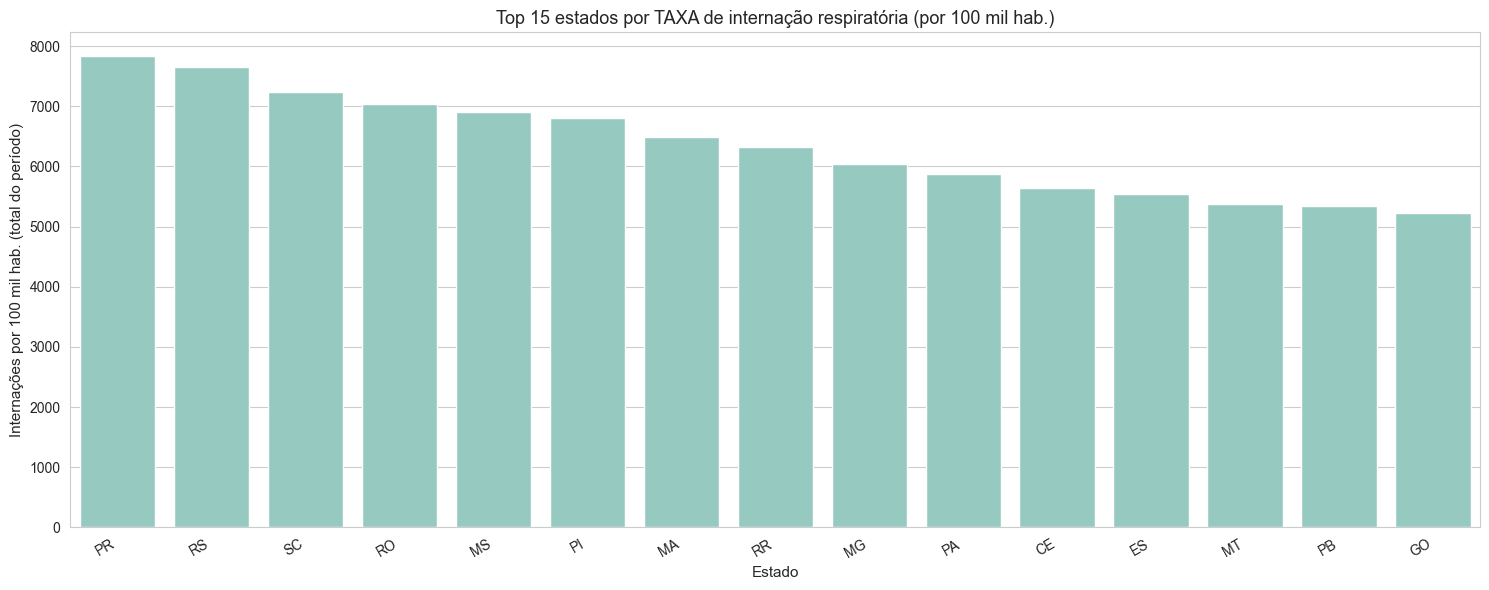

In [24]:
base = base.merge(df_pop, on=["Estado","Ano"], how="left")
print("Linhas sem população (deve ser 0):", base["Populacao"].isna().sum())
base["Internacoes_por_100k"] = base["Internacoes"] / base["Populacao"] * 100_000

ranking_taxa = (base.groupby("Estado")
                .apply(lambda g: g["Internacoes"].sum() / g["Populacao"].mean() * 100_000)
                .sort_values(ascending=False).reset_index(name="Internacoes_por_100k"))
print("\nRanking por TAXA (internações por 100 mil hab):")
print(ranking_taxa.head(10).to_string(index=False))

plt.figure(figsize=(15, 6))
sns.barplot(data=ranking_taxa.head(15), x="Estado", y="Internacoes_por_100k")
plt.title("Top 15 estados por TAXA de internação respiratória (por 100 mil hab.)")
plt.ylabel("Internações por 100 mil hab. (total do período)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

> **Leitura:** ao corrigir pela população, **SP some do topo** e quem lidera é o
> **Sul** (PR, RS, SC) — coerente com o inverno mais rigoroso do país e boa
> cobertura do SUS. Vários estados de queimada intensa (RO, MA, PA, MT) também
> sobem, o que reforça (timidamente) a hipótese da fumaça.

## 11. Teste de hipótese

**H0:** a internação após meses de queimada alta é igual à de meses de queimada
baixa. **H1:** é maior após queimada alta (teste unilateral).

Usamos **Mann-Whitney U** (não-paramétrico, pois os dados não são normais),
sobre **anomalias** e com **defasagem de 3 meses** (coerente com a seção 9).

In [25]:
LAG = 3
base["Inter_futura"] = base.groupby("Estado")["Inter_anom"].shift(-LAG)

def teste_hipotese(df, nome):
    d = df.dropna(subset=["Inter_futura","Focos_anom"])
    limiar = d[d["Focos_anom"] > 0]["Focos_anom"].quantile(0.75)
    alta  = d[d["Focos_anom"] >= limiar]["Inter_futura"]
    baixa = d[d["Focos_anom"] <  limiar]["Inter_futura"]
    u, p = stats.mannwhitneyu(alta, baixa, alternative="greater")
    return {"Grupo": nome, "n_alta": len(alta), "n_baixa": len(baixa),
            "mediana_alta": round(alta.median(),1), "mediana_baixa": round(baixa.median(),1),
            "p_valor": round(p,4),
            "Conclusao": "Rejeita H0 (efeito detectado)" if p < 0.05 else "Não rejeita H0"}

resultados = pd.DataFrame([
    teste_hipotese(base, "Brasil (27 estados)"),
    teste_hipotese(base[base["Regiao"]=="Sudeste"], "Sudeste"),
    teste_hipotese(base[base["Regiao"].isin(["Norte","Centro-Oeste"])], "Norte+Centro-Oeste"),
])
print(resultados.to_string(index=False))

              Grupo  n_alta  n_baixa  mediana_alta  mediana_baixa  p_valor                     Conclusao
Brasil (27 estados)     318     2841          47.4           41.1   0.3155                Não rejeita H0
            Sudeste      47      421         971.8           52.0   0.0263 Rejeita H0 (efeito detectado)
 Norte+Centro-Oeste     120     1167          17.8           14.8   0.6168                Não rejeita H0


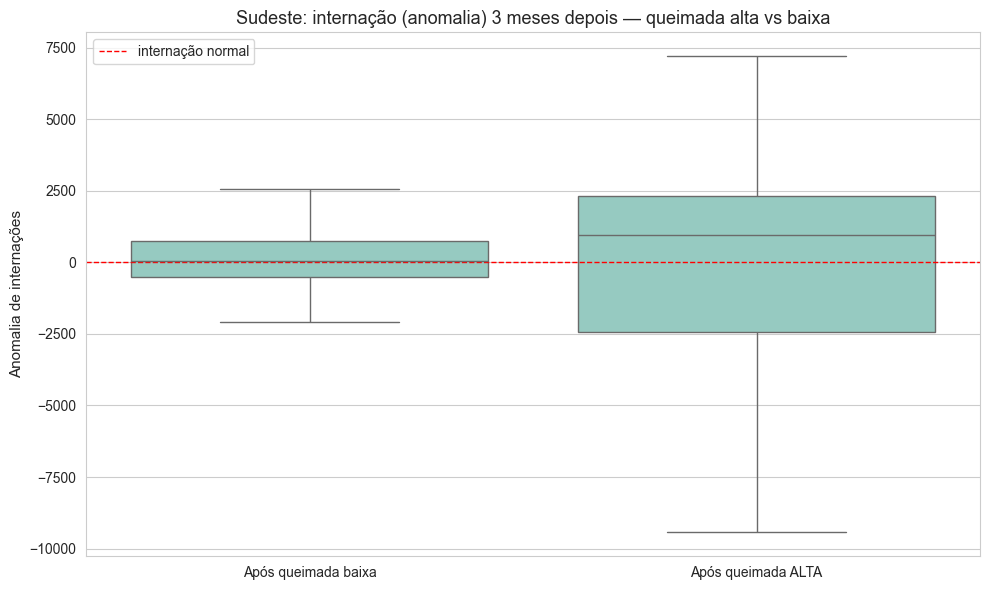

In [26]:
# distribuição que sustenta o teste (Sudeste, onde deu significativo)
sudeste = base[base["Regiao"]=="Sudeste"].dropna(subset=["Inter_futura","Focos_anom"]).copy()
limiar = sudeste[sudeste["Focos_anom"]>0]["Focos_anom"].quantile(0.75)
sudeste["Grupo"] = np.where(sudeste["Focos_anom"]>=limiar, "Após queimada ALTA", "Após queimada baixa")

plt.figure(figsize=(10, 6))
sns.boxplot(data=sudeste, x="Grupo", y="Inter_futura", showfliers=False)
plt.axhline(0, color="red", linestyle="--", linewidth=1, label="internação normal")
plt.title("Sudeste: internação (anomalia) 3 meses depois — queimada alta vs baixa")
plt.ylabel("Anomalia de internações"); plt.xlabel("")
plt.legend()
plt.tight_layout()
plt.show()

> **Leitura:** no **Sudeste** rejeitamos H0 (p ≈ 0,026): meses de queimada alta
> são seguidos, 3 meses depois, por internações acima do normal. No Brasil todo
> e no Norte+CO não rejeitamos. **Conclusão honesta:** há evidência
> **localizada** de associação defasada, não um efeito nacional uniforme. Como
> foram testados vários recortes, trata-se de um achado **exploratório** que
> precisaria de dados mais granulares (municípios, séries diárias) para confirmação.

## 12. Visualizações finais

Três gráficos que fecham os requisitos: matriz de correlação, série temporal
comparativa e taxa de variação anual.

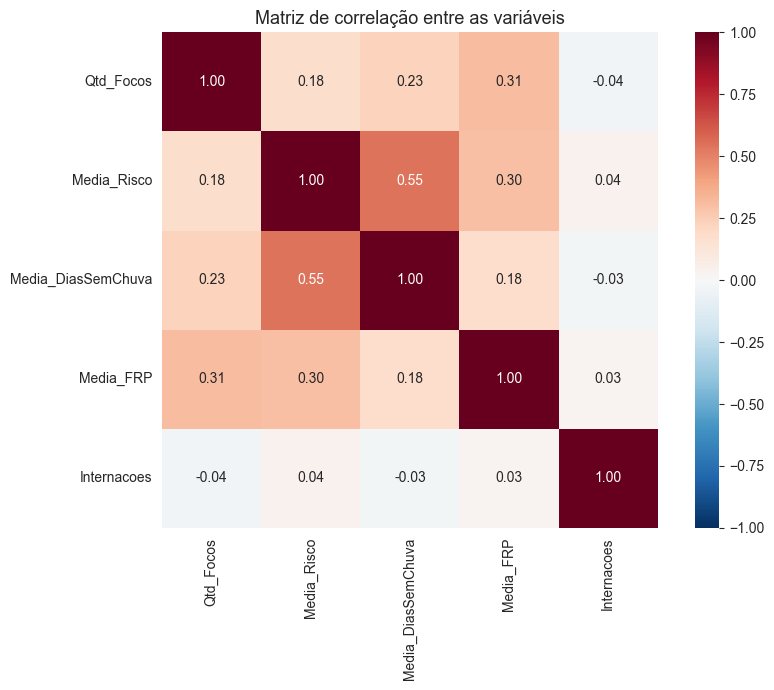

In [27]:
# 12.1 Matriz de correlação
cols = [c for c in ["Qtd_Focos","Media_Risco","Media_DiasSemChuva","Media_FRP","Internacoes"] if c in base.columns]
plt.figure(figsize=(9, 7))
sns.heatmap(base[cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlação entre as variáveis")
plt.tight_layout()
plt.show()

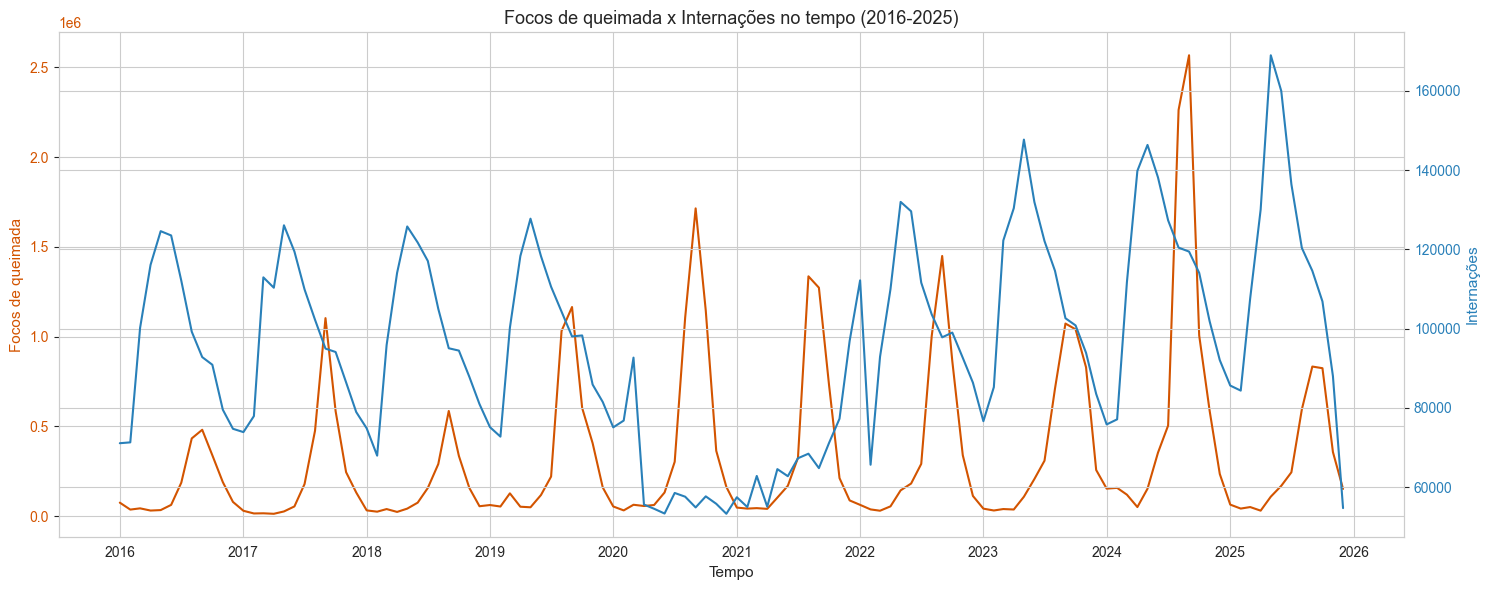

In [28]:
# 12.2 Série temporal comparativa (eixo duplo)
serie = (base.groupby(["Ano","Mes"]).agg(Focos=("Qtd_Focos","sum"),
                                         Inter=("Internacoes","sum")).reset_index())
serie["Data"] = pd.to_datetime(serie["Ano"].astype(str)+"-"+serie["Mes"].astype(str)+"-01")
serie = serie.sort_values("Data")

fig, ax1 = plt.subplots(figsize=(15, 6))
c1, c2 = "#d35400", "#2980b9"
ax1.plot(serie["Data"], serie["Focos"], color=c1, label="Focos")
ax1.set_xlabel("Tempo"); ax1.set_ylabel("Focos de queimada", color=c1)
ax1.tick_params(axis="y", labelcolor=c1)
ax2 = ax1.twinx()
ax2.plot(serie["Data"], serie["Inter"], color=c2, label="Internações")
ax2.set_ylabel("Internações", color=c2); ax2.tick_params(axis="y", labelcolor=c2)
plt.title("Focos de queimada x Internações no tempo (2016-2025)")
fig.tight_layout()
plt.show()

> **Leitura:** as duas curvas sobem e descem em **momentos diferentes** de cada
> ano (ondas fora de fase) — a explicação visual de por que a correlação no
> mesmo mês é nula. Visível também o vale da COVID (2020-21) e o pico de focos
> de 2024.

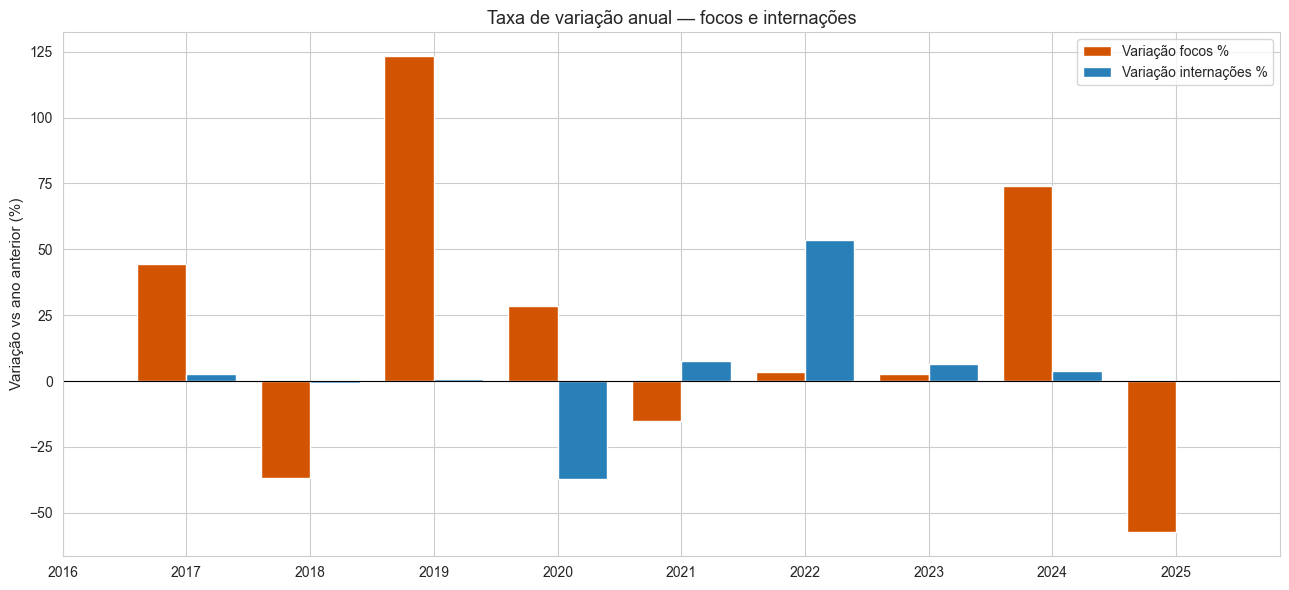

      Var_Focos_%  Var_Inter_%
Ano                           
2016          NaN          NaN
2017         44.5          2.7
2018        -36.8         -0.6
2019        123.3          0.9
2020         28.4        -37.4
2021        -15.1          7.7
2022          3.6         53.5
2023          2.5          6.4
2024         74.2          4.0
2025        -57.5         -0.5


In [29]:
# 12.3 Taxa de variação anual
anual = base.groupby("Ano").agg(Focos=("Qtd_Focos","sum"), Inter=("Internacoes","sum"))
anual["Var_Focos_%"] = anual["Focos"].pct_change()*100
anual["Var_Inter_%"] = anual["Inter"].pct_change()*100

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(anual.index)); w = 0.4
ax.bar(x-w/2, anual["Var_Focos_%"], w, label="Variação focos %", color=c1)
ax.bar(x+w/2, anual["Var_Inter_%"], w, label="Variação internações %", color=c2)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(anual.index)
ax.set_ylabel("Variação vs ano anterior (%)")
ax.set_title("Taxa de variação anual — focos e internações")
ax.legend()
plt.tight_layout()
plt.show()
print(anual[["Var_Focos_%","Var_Inter_%"]].round(1).to_string())

## 13. Uso do solo: área plantada × queimadas (4ª base)

Até aqui o cruzamento usou três bases (queimadas, internações e população).
Agora integramos uma **quarta base** — a **área plantada** por estado, do
**IBGE/PAM** (SIDRA tabela 5457, anos 2016–2024). Duas perguntas guiam a seção:

1. **O fogo acompanha a agricultura?** (correlação focos × área plantada)
2. **Onde o fogo é mais intenso _por hectare de lavoura_?** (indicador normalizado)

In [30]:
# 4ª base: área plantada por UF/ano (IBGE/PAM, tabela 5457) — cobre 2016–2024
df_area = pd.read_csv("dados/area_agricola_consolidado.csv")
print("Área plantada:", df_area.shape,
      "| anos:", int(df_area["Ano"].min()), "-", int(df_area["Ano"].max()),
      "| estados:", df_area["Estado"].nunique())

# integra à base mensal (a área é anual -> repete nos 12 meses do ano)
base = base.drop(columns=[c for c in ["Area_Agricola_Ha"] if c in base.columns])  # re-run seguro
base = base.merge(df_area[["Estado", "Ano", "Area_Agricola_Ha"]],
                  on=["Estado", "Ano"], how="left")

# indicadores normalizados
base["Focos_por_1000ha"] = base["Qtd_Focos"] / base["Area_Agricola_Ha"] * 1000
base["Focos_por_100k"]   = base["Qtd_Focos"] / base["Populacao"]        * 100_000
# (Internacoes_por_100k já foi criada na seção 10)

sem_area = int(base["Area_Agricola_Ha"].isna().sum())
print(f"base agora: {base.shape[1]} colunas | linhas sem área: {sem_area} (= meses de 2025, esperado)")

Área plantada: (243, 4) | anos: 2016 - 2024 | estados: 27
base agora: 17 colunas | linhas sem área: 324 (= meses de 2025, esperado)


> **Leitura:** o merge é 1:1 e a única ausência de área é em **2025**, ano que
> a PAM ainda não divulgou (por isso os indicadores por hectare usam 2016–2024).
> Passamos a ter três indicadores normalizados: **focos por 1.000 ha de lavoura**,
> **focos por 100 mil hab.** e **internações por 100 mil hab.**

### 13.1 O fogo acompanha a agricultura?

Pearson  (linear) : r = +0.391  (p = 0.043)
Spearman (rank)   : r = +0.469  (p = 0.013)
Pearson  (log-log): r = +0.456  (p = 0.017)


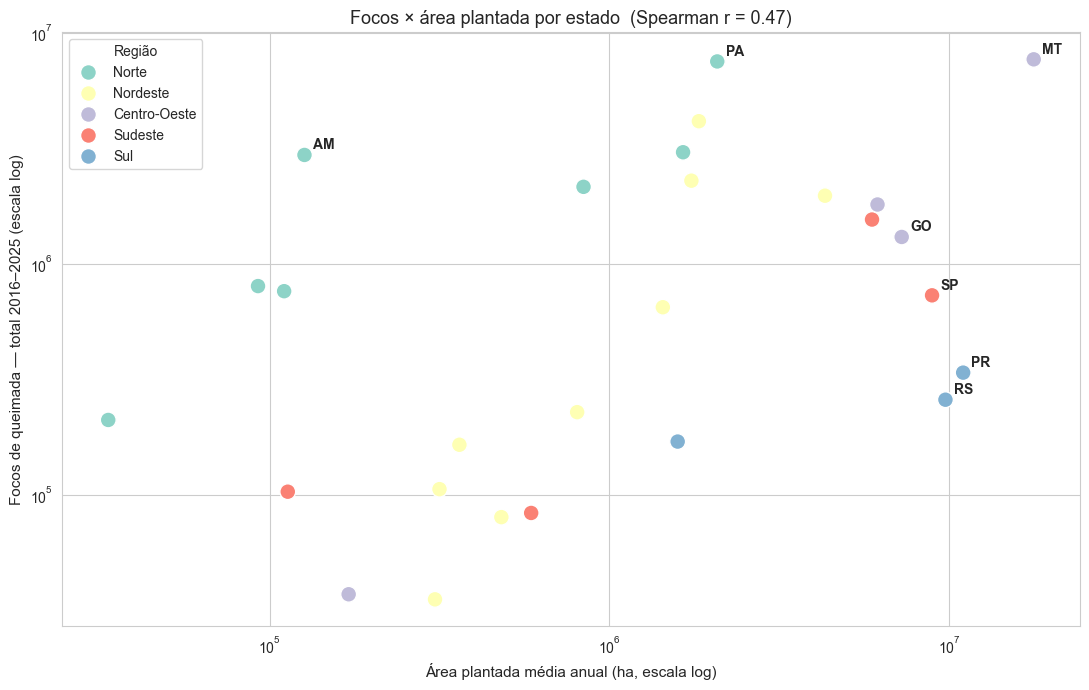

In [31]:
# agregado por estado: total de focos (2016–2025) × área plantada média anual (2016–2024)
focos_uf = base.groupby("Estado")["Qtd_Focos"].sum()
area_uf  = df_area.groupby("Estado")["Area_Agricola_Ha"].mean()
agro = pd.concat([focos_uf, area_uf], axis=1).reset_index()
agro.columns = ["Estado", "Focos", "Area_ha"]
agro["Regiao"] = agro["Estado"].map(regiao_sigla)

r,  p  = stats.pearsonr(agro["Area_ha"], agro["Focos"])
rs, ps = stats.spearmanr(agro["Area_ha"], agro["Focos"])
rl, pl = stats.pearsonr(np.log10(agro["Area_ha"]), np.log10(agro["Focos"]))
print(f"Pearson  (linear) : r = {r:+.3f}  (p = {p:.3f})")
print(f"Spearman (rank)   : r = {rs:+.3f}  (p = {ps:.3f})")
print(f"Pearson  (log-log): r = {rl:+.3f}  (p = {pl:.3f})")

plt.figure(figsize=(11, 7))
sns.scatterplot(data=agro, x="Area_ha", y="Focos", hue="Regiao", s=130,
                edgecolor="white", linewidth=1)
for _, row in agro.iterrows():
    if row["Estado"] in ["MT", "PA", "PR", "RS", "SP", "AM", "GO"]:
        plt.annotate(row["Estado"], (row["Area_ha"], row["Focos"]),
                     xytext=(6, 4), textcoords="offset points", fontweight="bold")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Área plantada média anual (ha, escala log)")
plt.ylabel("Focos de queimada — total 2016–2025 (escala log)")
plt.title(f"Focos × área plantada por estado  (Spearman r = {rs:.2f})")
plt.legend(title="Região"); plt.tight_layout(); plt.show()

> **Leitura:** a associação é **positiva, mas moderada** (Spearman ≈ 0,47).
> Não é mais forte porque **Paraná e Rio Grande do Sul plantam muito e queimam
> pouco** (agricultura mecanizada, clima úmido), enquanto **Mato Grosso** lidera
> nos dois. O fogo não acompanha a área plantada em si — acompanha a **fronteira
> agrícola avançando sobre biomas secos** (Cerrado e Amazônia).

### 13.2 Focos por hectare de lavoura — o fogo do Norte não é agrícola

Focos por 1.000 ha de lavoura — média estadual (2016–2024):

Estado  Focos_por_1000ha       Regiao
    AM             201.0        Norte
    AC              76.6        Norte
    RR              63.0        Norte
    AP              58.6        Norte
    PA              30.3        Norte
    RO              22.7        Norte
    MA              17.7     Nordeste
    TO              14.8        Norte
    PI              10.0     Nordeste
    RJ               7.6      Sudeste
    PB               3.7     Nordeste
    MT               3.7 Centro-Oeste
    CE               3.6     Nordeste
    BA               3.6     Nordeste
    RN               2.6     Nordeste
    MS               2.5 Centro-Oeste
    PE               2.2     Nordeste
    MG               2.1      Sudeste
    DF               1.8 Centro-Oeste
    GO               1.4 Centro-Oeste
    AL               1.4     Nordeste
    ES               1.2      Sudeste
    SE               0.9     Nordeste
    SC               0.9   

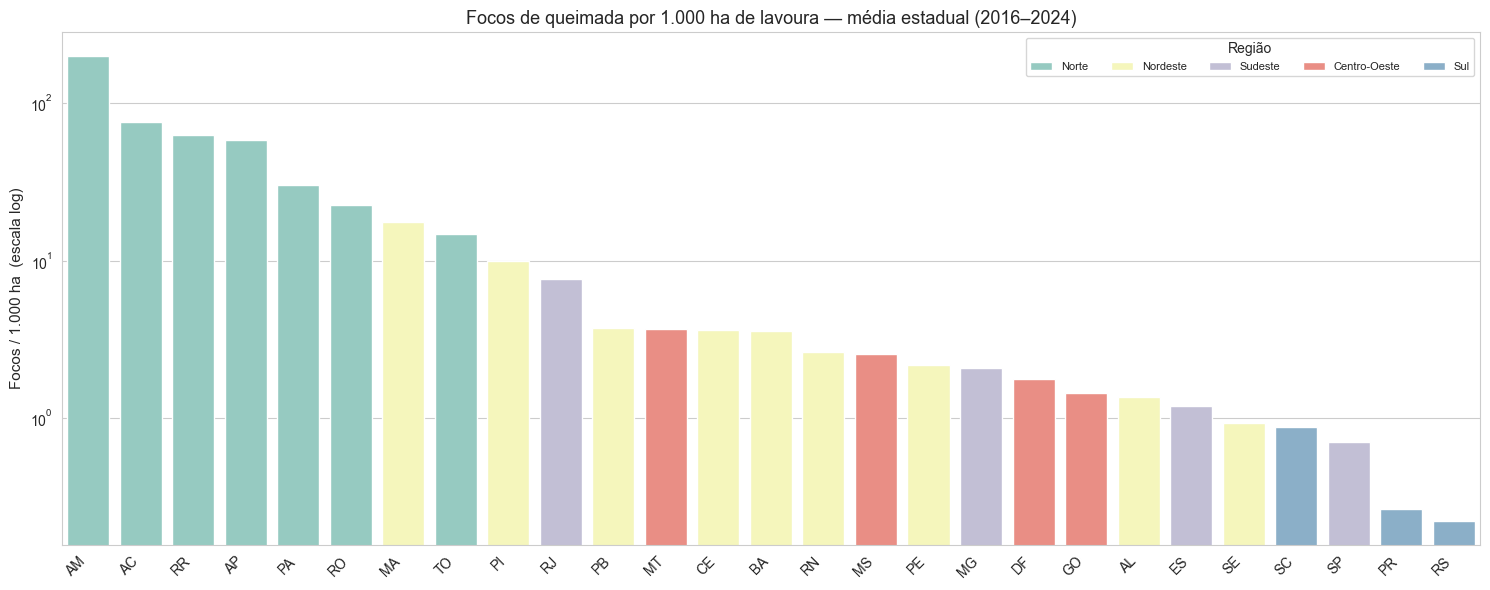

In [32]:
rank_ha = (base.dropna(subset=["Focos_por_1000ha"])
               .groupby("Estado")["Focos_por_1000ha"].mean()
               .sort_values(ascending=False).reset_index())
rank_ha["Regiao"] = rank_ha["Estado"].map(regiao_sigla)
print("Focos por 1.000 ha de lavoura — média estadual (2016–2024):\n")
print(rank_ha.round(1).to_string(index=False))

plt.figure(figsize=(15, 6))
sns.barplot(data=rank_ha, x="Estado", y="Focos_por_1000ha", hue="Regiao", dodge=False)
plt.yscale("log")
plt.title("Focos de queimada por 1.000 ha de lavoura — média estadual (2016–2024)")
plt.ylabel("Focos / 1.000 ha  (escala log)")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Região", ncol=5, fontsize=8)
plt.tight_layout(); plt.show()

> **Leitura — achado novo:** normalizado pela agricultura, o ranking **se
> inverte**. Os estados **amazônicos** disparam (AM ≈ 201, AC ≈ 77, RR ≈ 63 focos
> por 1.000 ha) e o **Sul** afunda (RS ≈ 0,2; PR ≈ 0,3) — uma diferença de quase
> **900×** entre AM e RS. A leitura é direta: no Norte, o fogo **não é manejo
> agrícola**, é **abertura/limpeza de área**; onde a agricultura é consolidada e
> mecanizada (Sul), quase não se queima. Isso reforça o argumento central do
> BreathAlert: o risco é **local e estrutural**, não capturável por médias nacionais.

## 14. Conclusão

**O que os dados mostram.** Queimadas e internações respiratórias seguem
calendários **diferentes**: as queimadas sobem na seca (ago–out) e as
internações no inverno (abr–jun). Por isso, no mesmo mês, não há correlação
direta — e a correlação ingênua, contaminada por população e sazonalidade,
chega a ser negativa.

**O sinal existe, mas é fraco e localizado.** Após remover a sazonalidade
(anomalias) e aplicar defasagem, surge uma associação **positiva** que cresce
com o atraso — coerente com o efeito cumulativo da fumaça sobre a saúde. Esse
sinal é mais nítido no **Sudeste**, onde a grande população permite medir as
variações com menos ruído; lá, o teste de hipótese confirma (p < 0,05) que
meses de queimada intensa são seguidos, ~3 meses depois, por internações acima
do normal.

**Por que isso importa para o BreathAlert.** A própria fraqueza do sinal na
média nacional é o argumento do produto: o impacto da fumaça se **dilui** nas
estatísticas agregadas, tornando-se quase invisível justamente onde as decisões
de saúde pública são tomadas. Um sistema de alerta precisa, portanto, atuar de
forma **local e antecipada** — usando a seca (que sobe **antes** dos focos) como
gatilho precoce — para proteger as populações expostas antes que o efeito
apareça, tarde, nas internações.

**O uso do solo qualifica o diagnóstico.** Cruzando a **área plantada** (IBGE/PAM), vimos que o fogo se associa à agricultura apenas de forma **moderada** (Spearman ≈ 0,47). Normalizado por hectare de lavoura, o fogo do Norte (AM ≈ 201 focos/1.000 ha) supera o do Sul (RS ≈ 0,2) em quase **900×** — evidência de **dois regimes de fogo**: abertura de área na fronteira amazônica vs. manejo consolidado no Sul. Isso reforça que a resposta de saúde precisa ser **regionalizada**.

**Limitações.** Escala mensal e estadual é grosseira para um fenômeno local;
os achados por recorte são exploratórios (múltiplas comparações); 2025 pode
estar levemente subestimado pela defasagem do SIH, e a área plantada (PAM)
cobre 2016–2024. Próximos
passos: dados municipais e diários, e controle por outras variáveis (vírus
sazonais, temperatura).